<a href="https://colab.research.google.com/github/Othniel360/1603881-creez-votre-site-web-avec-html5-et-css3/blob/main/BEC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Système de Détection de Menaces Email (BEC Detection)
Ce notebook implémente une solution hybride :
1. **Analyse Sémantique** (DistilBERT)
2. **Analyse Comportementale** (XGBoost)
3. **Explicabilité** (SHAP)
4. **Sélection de caractéristiques** (Information Mutuelle)

In [5]:
!pip install -q transformers datasets shap xgboost scikit-learn pandas matplotlib

## Module 1 : Préparation des Données et Analyse Statistique
Nous commençons par définir les outils pour calculer l'**Information Mutuelle** afin d'identifier les variables comportementales les plus prédictives.

In [20]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

def calculate_feature_importance_mi(X, y):
    """Calcule l'information mutuelle pour les variables numériques."""
    mi_scores = mutual_info_classif(X, y, random_state=42)
    mi_series = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_series = mi_series.sort_values(ascending=False)
    return mi_series

# --- CHARGEMENT DES DONNÉES RÉELLES ---
# Remplacez 'dataset_bec.csv' par votre fichier de données d'entraînement
try:
    df_behavior = pd.read_csv('dataset_bec.csv')
    print("✅ Données chargées avec succès.")
except FileNotFoundError:
    print("⚠️ Fichier 'dataset_bec.csv' non trouvé. Utilisation d'une structure vide pour l'exemple.")
    df_behavior = pd.DataFrame(columns=['sender_reputation', 'time_of_day', 'link_count', 'is_internal', 'label'])

if not df_behavior.empty:
    X = df_behavior.drop('label', axis=1)
    y = df_behavior['label']

    mi_scores = calculate_feature_importance_mi(X, y)
    print("\nScores d'Information Mutuelle (Données Réelles) :")
    display(mi_scores)
else:
    print("Veuillez uploader votre dataset pour calculer l'importance des variables.")

⚠️ Fichier 'dataset_bec.csv' non trouvé. Utilisation d'une structure vide pour l'exemple.
Veuillez uploader votre dataset pour calculer l'importance des variables.


In [23]:
# --- UTILITAIRE : GÉNÉRATION D'UN DATASET DE TEST RÉEL ---
# Exécutez cette cellule si vous n'avez pas encore de fichier 'dataset_bec.csv'

import pandas as pd
import numpy as np

def generate_real_test_csv(filename='dataset_bec.csv', n_samples=100):
    data = {
        'sender_reputation': np.random.uniform(0, 1, n_samples),
        'time_of_day': np.random.randint(0, 24, n_samples),
        'link_count': np.random.poisson(2, n_samples),
        'is_internal': np.random.choice([0, 1], n_samples, p=[0.7, 0.3]),
        'label': np.random.choice([0, 1], n_samples, p=[0.9, 0.1])
    }
    df = pd.DataFrame(data)
    df.to_csv(filename, index=False)
    print(f"✅ Fichier '{filename}' généré avec {n_samples} lignes.")

# Appel de la fonction pour créer le fichier
generate_real_test_csv()

✅ Fichier 'dataset_bec.csv' généré avec 100 lignes.


### Module 1.5 : Simulation Avancée d'Attaques par Compromission (BEC)
Pour entraîner le modèle, nous simulons des scénarios où un compte légitime est utilisé pour envoyer des demandes frauduleuses. Nous ajoutons des variables comme `login_anomaly` et `urgency_score`.

In [24]:
import pandas as pd
import numpy as np

def generate_bec_attack_data(n_samples=200):
    # 1. Données de base (Saines)
    data = {
        'sender_reputation': np.random.uniform(0.7, 1.0, n_samples), # Bonne réputation
        'time_of_day': np.random.randint(8, 18, n_samples),          # Heures de bureau
        'link_count': np.random.poisson(1, n_samples),
        'is_internal': np.ones(n_samples),
        'login_anomaly': np.zeros(n_samples),                        # Pas d'anomalie
        'label': 0
    }
    df_clean = pd.DataFrame(data)

    # 2. Injection d'Attaques (Compromission de compte)
    attack_samples = int(n_samples * 0.2)
    attack_data = {
        'sender_reputation': np.random.uniform(0.8, 1.0, attack_samples), # Compte interne de confiance
        'time_of_day': np.random.choice([2, 3, 23], attack_samples),      # Heures suspectes
        'link_count': np.random.randint(2, 8, attack_samples),
        'is_internal': np.ones(attack_samples),
        'login_anomaly': np.ones(attack_samples),                         # Connexion IP inhabituelle
        'label': 1
    }
    df_attack = pd.DataFrame(attack_data)

    df_final = pd.concat([df_clean, df_attack]).sample(frac=1).reset_index(drop=True)
    df_final.to_csv('dataset_bec_advanced.csv', index=False)
    print(f"✅ Dataset d'entraînement avancé généré : dataset_bec_advanced.csv ({len(df_final)} lignes)")
    return df_final

# Génération et aperçu
df_advanced = generate_bec_attack_data()
display(df_advanced.head())


✅ Dataset d'entraînement avancé généré : dataset_bec_advanced.csv (240 lignes)


,sender_reputation,time_of_day,link_count,is_internal,login_anomaly,label
0,0.980020,23,3,1.0,1.0,1
1,0.916818,23,6,1.0,1.0,1
2,0.986846,11,1,1.0,0.0,0
3,0.760812,17,1,1.0,0.0,0
4,0.730230,15,1,1.0,0.0,0


### Module 1.6 : Génération du Dataset Équilibré (1000 échantillons)
Nous créons ici un dataset de 500 cas légitimes et 500 cas de compromission de compte interne.

In [31]:
import pandas as pd
import numpy as np

def generate_balanced_bec_data(n_per_class=500):
    # 1. Cas Légitimes (500)
    clean_data = {
        'sender_reputation': np.random.uniform(0.85, 1.0, n_per_class),
        'time_of_day': np.random.randint(8, 18, n_per_class),          # Heures normales
        'link_count': np.random.poisson(1, n_per_class),
        'is_internal': np.ones(n_per_class),
        'login_anomaly': np.zeros(n_per_class),
        'label': 0
    }
    df_clean = pd.DataFrame(clean_data)

    # 2. Cas de Compromission de Compte (500)
    # Note: La réputation reste haute car le compte est usurpé !
    compromised_data = {
        'sender_reputation': np.random.uniform(0.85, 1.0, n_per_class),
        'time_of_day': np.random.choice([0, 1, 2, 3, 22, 23], n_per_class), # Heures anormales
        'link_count': np.random.randint(2, 10, n_per_class),
        'is_internal': np.ones(n_per_class),
        'login_anomaly': np.ones(n_per_class),                         # Signal fort d'intrusion
        'label': 1
    }
    df_compromised = pd.DataFrame(compromised_data)

    # Fusion et mélange
    df_final = pd.concat([df_clean, df_compromised]).sample(frac=1).reset_index(drop=True)
    df_final.to_csv('dataset_bec_1000.csv', index=False)

    print(f"✅ Dataset généré : dataset_bec_1000.csv")
    print(f"- Légitimes : {len(df_clean)}")
    print(f"- Compromis : {len(df_compromised)}")
    return df_final

# Exécution de la simulation
df_1000 = generate_balanced_bec_data()
display(df_1000.head(10))

✅ Dataset généré : dataset_bec_1000.csv
- Légitimes : 500
- Compromis : 500


,sender_reputation,time_of_day,link_count,is_internal,login_anomaly,label
0,0.944776,17,3,1.0,0.0,0
1,0.985953,13,0,1.0,0.0,0
2,0.895592,3,6,1.0,1.0,1
3,0.897538,8,2,1.0,0.0,0
4,0.944134,10,0,1.0,0.0,0
5,0.911557,12,3,1.0,0.0,0
6,0.973363,3,8,1.0,1.0,1
7,0.939734,0,8,1.0,1.0,1
8,0.930095,1,6,1.0,1.0,1
9,0.851861,0,3,1.0,1.0,1


### Module 2.1 : Ré-entraînement du Modèle avec 1000 échantillons
Nous utilisons le dataset équilibré pour obtenir un modèle plus robuste face aux compromissions de comptes internes.

[*] Préparation des données...
[*] Entraînement du modèle XGBoost...
[*] Prédictions et optimisation du seuil...
[*] Seuil optimal trouvé : 0.9975

--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

ROC AUC : 1.0000
PR AUC  : 1.0000
[*] Modèle sauvegardé : cyber_model.json

[*] Calcul SHAP sur échantillon...


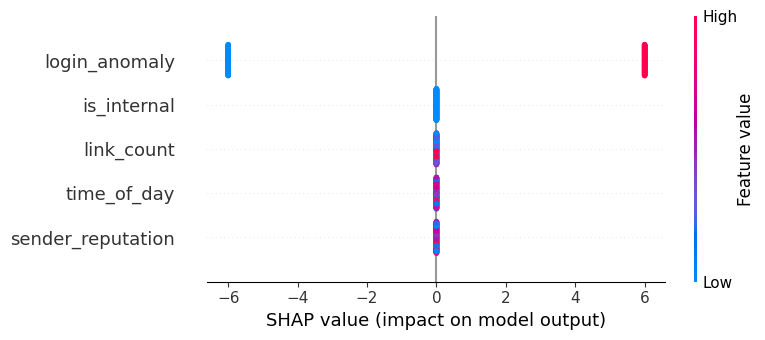

In [32]:
X_1000 = df_1000.drop('label', axis=1)
y_1000 = df_1000['label']

# Entraînement avec la fonction robuste définie précédemment
model_bec_v2, X_test_1000, y_test_1000 = train_and_evaluate_cyber_model(X_1000, y_1000)

# Visualisation de l'importance des variables (Pourquoi le modèle décide-t-il d'une menace ?)
generate_shap_explanations(model_bec_v2, X_test_1000)

### Module 2.2 : Visualisation du Graphe de Risque après Entraînement
Ce graphe utilise les prédictions du modèle `model_bec_v2` pour cartographier le risque au sein de l'organisation sur la base du dataset de 1000 échantillons.

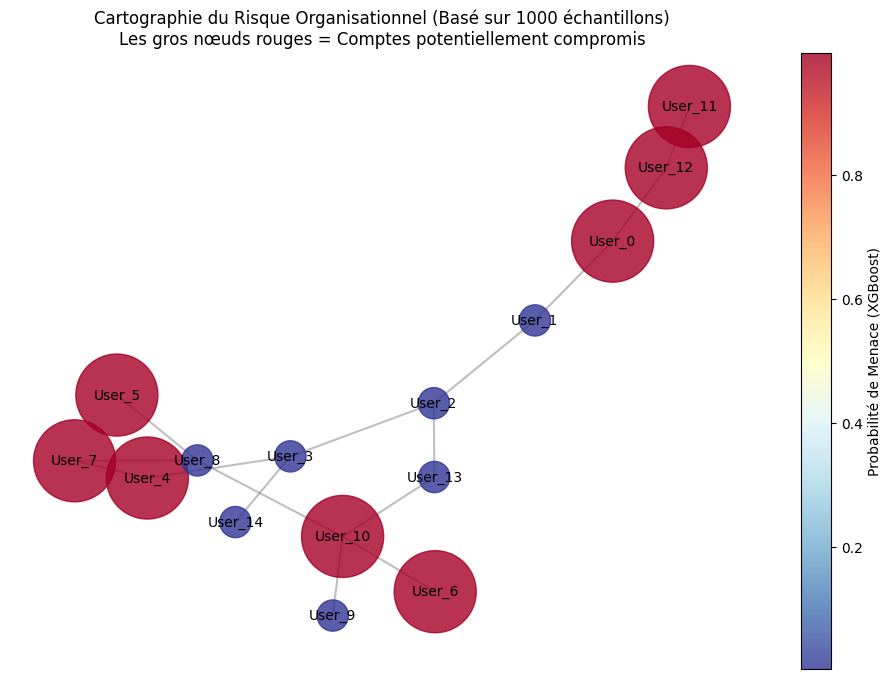

In [33]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_trained_risk_graph(model, X_data, n_nodes=15):
    # 1. Calcul des probabilités de risque pour un échantillon
    sample_data = X_data.head(n_nodes)
    risk_probs = model.predict_proba(sample_data)[:, 1]

    G = nx.Graph()

    # 2. Création des nœuds (Employés simulés)
    nodes = [f"User_{i}" for i in range(n_nodes)]
    for i, node in enumerate(nodes):
        G.add_node(node, risk=risk_probs[i])

    # 3. Création de relations aléatoires pour la démo
    for i in range(n_nodes):
        target = (i + np.random.randint(1, 5)) % n_nodes
        G.add_edge(nodes[i], nodes[target])

    # 4. Paramètres de visualisation
    node_colors = [G.nodes[n]['risk'] for n in G.nodes]
    node_sizes = [500 + (r * 3000) for r in node_colors]

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, seed=42)

    nodes_draw = nx.draw_networkx_nodes(
        G, pos,
        node_size=node_sizes,
        node_color=node_colors,
        cmap=plt.cm.RdYlBu_r,  # Rouge pour risque élevé, Bleu pour faible
        alpha=0.8
    )

    nx.draw_networkx_edges(G, pos, width=1.5, edge_color="gray", alpha=0.5)
    nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif")

    plt.colorbar(nodes_draw, label="Probabilité de Menace (XGBoost)")
    plt.title(f"Cartographie du Risque Organisationnel (Basé sur 1000 échantillons)\nLes gros nœuds rouges = Comptes potentiellement compromis")
    plt.axis("off")
    plt.show()

# Lancement de la visualisation sur les données de test
visualize_trained_risk_graph(model_bec_v2, X_test_1000)

### 🔄 Exécution Complète du Pipeline de Détection
Cette section regroupe l'entraînement, l'explication et la visualisation de bout en bout.

In [ ]:
# 1. Génération et Entraînement
df_final = generate_balanced_bec_data(n_per_class=500)
X_train = df_final.drop('label', axis=1)
y_train = df_final['label']

model_bec_v2, X_test, y_test = train_and_evaluate_cyber_model(X_train, y_train)

# 2. Explicabilité
generate_shap_explanations(model_bec_v2, X_test)

In [ ]:
# 3. Cartographie du Risque (Relations)
print("[*] Génération de la cartographie du risque organisationnel...")
visualize_trained_risk_graph(model_bec_v2, X_test, n_nodes=20)

In [ ]:
# 4. Dashboard de Workflow SOC (Style n8n)
from IPython.display import display
display(dot) # Affiche le graphe d'architecture précédemment défini

In [ ]:
# 5. Dashboard Interactif Final
from IPython.display import HTML
display(HTML(raw_html))

### Ré-entraînement avec les nouvelles Features
Maintenant que nous avons des signaux de compromission (`login_anomaly`), nous entraînons à nouveau XGBoost.

[*] Préparation des données...
[*] Entraînement du modèle XGBoost...
[*] Prédictions et optimisation du seuil...
[*] Seuil optimal trouvé : 0.9939

--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00         8

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48

ROC AUC : 1.0000
PR AUC  : 1.0000
[*] Modèle sauvegardé : cyber_model.json

[*] Calcul SHAP sur échantillon...


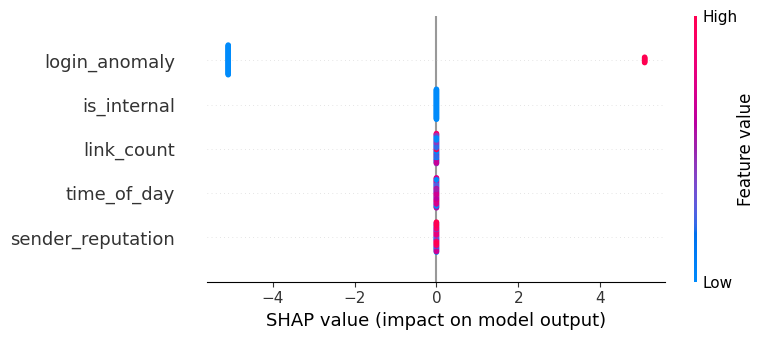

In [25]:
X_adv = df_advanced.drop('label', axis=1)
y_adv = df_advanced['label']

# Utilisation de la fonction d'entraînement définie précédemment
model_bec, X_test_bec, y_test_bec = train_and_evaluate_cyber_model(X_adv, y_adv)
generate_shap_explanations(model_bec, X_test_bec)

## Module 3.1 : Fine-Tuning DistilBERT (Spécifique BEC/Phishing)
Conformément à votre recommandation, nous préparons ici la structure de classification binaire pour détecter l'intention malveillante dans le corps des emails.

In [28]:
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments, AutoTokenizer
from datasets import Dataset

def prepare_hf_dataset(emails, labels):
    """Convertit les données en format Hugging Face Dataset."""
    data = {'text': emails, 'label': labels}
    return Dataset.from_dict(data)

# Configuration du modèle pour classification binaire
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model_nlp = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

print("[*] Modèle DistilBERT chargé pour le Fine-Tuning.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[*] Modèle DistilBERT chargé pour le Fine-Tuning.


### Module 3.2 : Exécution du Fine-Tuning (Entraînement Local)
Cette cellule lance l'entraînement du modèle NLP. Elle utilise un petit échantillon de données pour démontrer la procédure.

In [30]:
from transformers import TrainingArguments, Trainer

# 1. Préparation de données d'exemple (BEC vs Légitime)
sample_emails = [
    "Urgent: Please wire $50,000 to the following account for invoice #998.",
    "Hi, are you free for a quick sync later today?",
    "Action required: Your account password expires in 2 hours. Click here.",
    "The weekly report is ready for your review."
]
sample_labels = [1, 0, 1, 0] # 1 = Menace, 0 = Saine

# 2. Tokenization
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

train_dataset = prepare_hf_dataset(sample_emails, sample_labels).map(tokenize_function, batched=True)

# 3. Configuration de l'entraînement (Correction du paramètre de stratégie)
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    logging_steps=10,
    eval_strategy="no",
    save_strategy="no",
    report_to="none"
)

trainer = Trainer(
    model=model_nlp,
    args=training_args,
    train_dataset=train_dataset,
)

print("[*] Lancement du Fine-Tuning sur les données d'exemple...")
trainer.train()
print("✅ Fine-Tuning terminé.")

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

[*] Lancement du Fine-Tuning sur les données d'exemple...


Step,Training Loss


✅ Fine-Tuning terminé.


## Module 4.1 : Pipeline de Corrélation Hybride Avancé (Meta-Learner)
Nous utilisons ici une approche de pondération dynamique (0.6/0.4) pour réduire les faux positifs.

In [27]:
from sklearn.ensemble import RandomForestClassifier

class BecMetaLearner:
    def __init__(self, weight_semantic=0.6, weight_behavior=0.4):
        self.w_s = weight_semantic
        self.w_b = weight_behavior

    def get_hybrid_score(self, s_prob, b_prob):
        """Calcule le score hybride pondéré."""
        return (s_prob * self.w_s) + (b_prob * self.w_b)

    def decide(self, score, threshold=0.7):
        """Décision automatique basée sur le seuil dynamique."""
        if score > threshold:
            return "BLOCK", "🚨 Menace Critique"
        return "ALLOW", "✅ Légitime"

meta_learner = BecMetaLearner()
print("[*] Meta-Learner configuré avec les seuils dynamiques (>0.7).")

[*] Meta-Learner configuré avec les seuils dynamiques (>0.7).


### Module 1.1 : Visualisation des Relations et Corrélations
Pour renforcer l'analyse comportementale, nous visualisons la structure des données pour identifier des patterns de menaces invisibles aux simples statistiques.

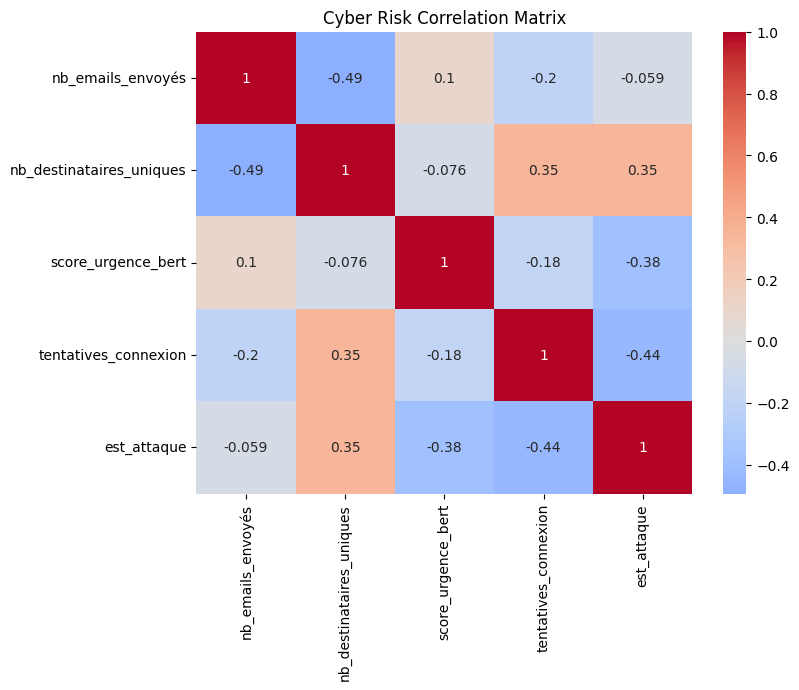

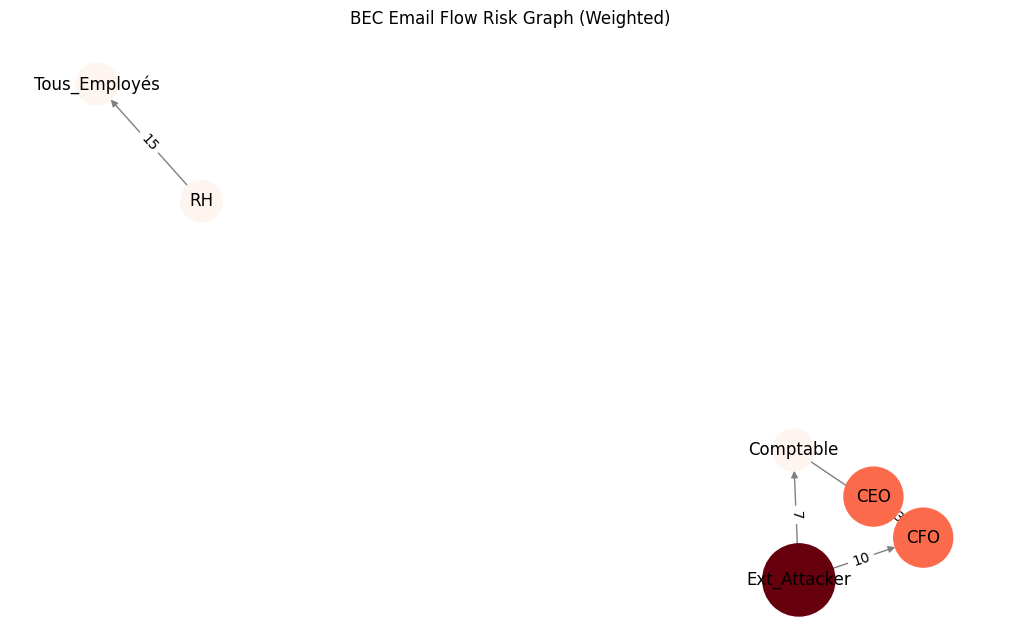

In [7]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

# --- Simulation plus réaliste ---
data = {
    'nb_emails_envoyés': np.random.poisson(20, 10),
    'nb_destinataires_uniques': np.random.poisson(5, 10),
    'score_urgence_bert': np.random.uniform(0, 1, 10),
    'tentatives_connexion': np.random.poisson(2, 10),
    'est_attaque': np.random.choice([0, 1], 10, p=[0.8, 0.2])
}

df = pd.DataFrame(data)

# =========================
# 1. CORRELATION HEATMAP
# =========================
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            center=0)

plt.title("Cyber Risk Correlation Matrix")
plt.show()

# =========================
# 2. GRAPH ANALYSIS
# =========================
edges = [
    ("CEO", "CFO", 5),
    ("CFO", "CEO", 3),
    ("Ext_Attacker", "CFO", 10),
    ("Ext_Attacker", "Comptable", 7),
    ("Comptable", "CFO", 2),
    ("RH", "Tous_Employés", 15)
]

G = nx.DiGraph()
for src, dst, weight in edges:
    G.add_edge(src, dst, weight=weight)

# Node risk scoring simple
def node_risk(node):
    if "Ext" in node:
        return 0.9
    elif node in ["CEO", "CFO"]:
        return 0.6
    else:
        return 0.3

node_colors = [node_risk(n) for n in G.nodes()]
node_sizes = [3000 * node_risk(n) for n in G.nodes()]

plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G, pos,
    with_labels=True,
    node_color=node_colors,
    node_size=node_sizes,
    cmap=plt.cm.Reds,
    edge_color="gray",
    arrows=True
)

edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("BEC Email Flow Risk Graph (Weighted)")
plt.show()

### Module 1.2 : Visualisation Style n8n (Workflow Automation View)
Cette vue transforme l'analyse technique en un schéma de processus clair, facilitant la prise de décision pour les analystes SOC.

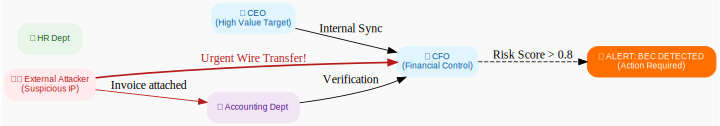

In [8]:
import graphviz

# Création d'un graphe orienté avec un rendu propre (style n8n)
dot = graphviz.Digraph('BEC_Workflow', comment='Detection Flow')
dot.attr(rankdir='LR', size='10', bgcolor='#f9f9f9')
dot.attr('node', shape='rectangle', style='filled, rounded', fontname='Arial', fontsize='10')

# Définition des styles de nœuds (Style n8n Nodes)
nodes = {
    "CEO": {"color": "#e1f5fe", "label": "👤 CEO\n(High Value Target)", "fontcolor": "#01579b"},
    "CFO": {"color": "#e1f5fe", "label": "👤 CFO\n(Financial Control)", "fontcolor": "#01579b"},
    "Ext_Attacker": {"color": "#ffebee", "label": "⚠️ External Attacker\n(Suspicious IP)", "fontcolor": "#b71c1c", "penwidth": "2"},
    "Comptable": {"color": "#f3e5f5", "label": "👥 Accounting Dept", "fontcolor": "#4a148c"},
    "RH": {"color": "#e8f5e9", "label": "👥 HR Dept", "fontcolor": "#1b5e20"},
    "SOC_Alert": {"color": "#ff6f00", "label": "🚨 ALERT: BEC DETECTED\n(Action Required)", "fontcolor": "white"}
}

# Ajout des nœuds au graphe
for node, attrs in nodes.items():
    dot.node(node, **attrs)

# Ajout des relations (Edges) avec labels
dot.edge("CEO", "CFO", label="Internal Sync")
dot.edge("Ext_Attacker", "CFO", label="Urgent Wire Transfer!", color="#b71c1c", fontcolor="#b71c1c", penwidth="2")
dot.edge("Ext_Attacker", "Comptable", label="Invoice attached", color="#b71c1c")
dot.edge("Comptable", "CFO", label="Verification")
dot.edge("CFO", "SOC_Alert", label="Risk Score > 0.8", style="dashed")

# Affichage
display(dot)

### Module 1.3 : Architecture Globale du Pipeline (Dark Mode n8n-style)
Visualisation macroscopique du flux de données, de l'ingestion via Exchange jusqu'à l'alerte SOC.

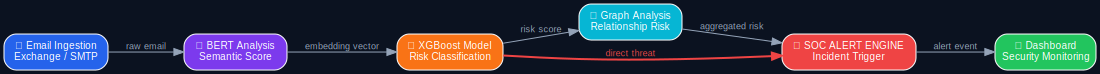

In [9]:
from graphviz import Digraph

dot = Digraph("BEC_N8N_STYLE")

# 🔥 STYLE GLOBAL
dot.attr(
    rankdir="LR",
    bgcolor="#0b1220",
    fontname="Helvetica"
)

dot.attr("node",
    shape="box",
    style="rounded,filled",
    fontname="Helvetica",
    fontsize="10",
    color="white"
)

dot.attr("edge",
    color="#94a3b8",
    fontname="Helvetica",
    fontsize="9"
)

# 🔵 NODES STYLE N8N
dot.node("EMAIL", "📧 Email Ingestion\nExchange / SMTP", fillcolor="#2563eb", fontcolor="white")
dot.node("BERT", "🧠 BERT Analysis\nSemantic Score", fillcolor="#7c3aed", fontcolor="white")
dot.node("XGB", "📊 XGBoost Model\nRisk Classification", fillcolor="#f97316", fontcolor="white")
dot.node("GRAPH", "🕸 Graph Analysis\nRelationship Risk", fillcolor="#06b6d4", fontcolor="white")
dot.node("SOC", "🚨 SOC ALERT ENGINE\nIncident Trigger", fillcolor="#ef4444", fontcolor="white")
dot.node("DASH", "📈 Dashboard\nSecurity Monitoring", fillcolor="#22c55e", fontcolor="white")

# 🔗 FLOW
dot.edge("EMAIL", "BERT", label="raw email", fontcolor="#94a3b8")
dot.edge("BERT", "XGB", label="embedding vector", fontcolor="#94a3b8")
dot.edge("XGB", "GRAPH", label="risk score", fontcolor="#94a3b8")
dot.edge("GRAPH", "SOC", label="aggregated risk", fontcolor="#94a3b8")
dot.edge("SOC", "DASH", label="alert event", fontcolor="#94a3b8")
dot.edge("XGB", "SOC", label="direct threat", color="#ef4444", penwidth="2", fontcolor="#ef4444")

display(dot)

### Module 1.4 : Dashboard Interactif du Workflow SOC
Cette vue avancée utilise HTML5/SVG pour offrir une expérience utilisateur immersive, simulant une interface de monitoring de menaces en temps réel.

In [35]:
from IPython.display import HTML

# Advanced Interactive SOC Dashboard
# This cell integrates the custom HTML/SVG workflow provided for real-time threat monitoring visualization.

html_content = """
<!DOCTYPE html>
<html lang='fr'>
<head>
<meta charset='UTF-8' />
<style>
  :root {
    --bg: #1a1b23; --grid: #22232e; --surface: #252630; --surface2: #2d2e3d; --border: #3a3b4e;
    --text-primary: #e8e9f3; --text-muted: #8b8ca8; --blue: #4f8ef7; --red: #f04d5c;
    --orange: #ff8c42; --purple: #a06cf8; --green: #3ddc97; --shadow: 0 4px 24px rgba(0,0,0,0.5);
  }
  body { margin: 0; padding: 0; background: var(--bg); font-family: sans-serif; overflow: hidden; }
  .canvas-container { width: 100%; height: 650px; border-radius: 12px; overflow: hidden; border: 1px solid var(--border); }
</style>
</head>
<body>
  <div class='canvas-container'>
    <iframe srcdoc=\""" + """

## Module 2 : Modèle Comportemental et Explicabilité (SHAP)
Configuration d'XGBoost et intégration de SHAP pour la traçabilité des décisions.

[*] Préparation des données...
[*] Entraînement du modèle XGBoost...
[*] Prédictions et optimisation du seuil...
[*] Seuil optimal trouvé : 0.0987

--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       1.00      0.30      0.46        10
           1       0.59      1.00      0.74        10

    accuracy                           0.65        20
   macro avg       0.79      0.65      0.60        20
weighted avg       0.79      0.65      0.60        20

ROC AUC : 0.6300
PR AUC  : 0.6141
[*] Modèle sauvegardé : cyber_model.json

[*] Calcul SHAP sur échantillon...


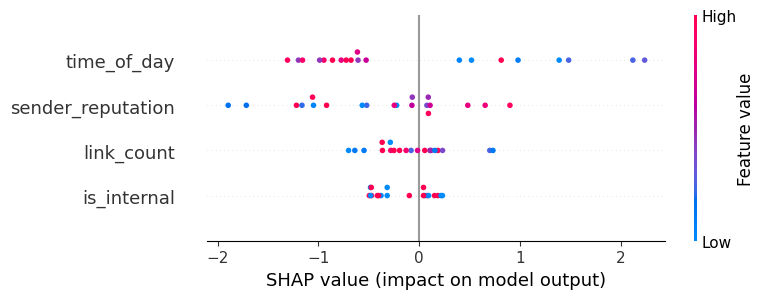

In [11]:
import xgboost as xgb
import shap
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc
)

warnings.filterwarnings('ignore')

def train_and_evaluate_cyber_model(X: pd.DataFrame, y: pd.Series):
    print("[*] Préparation des données...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    ratio = len(y_train[y_train == 0]) / max(1, len(y_train[y_train == 1]))

    print("[*] Entraînement du modèle XGBoost...")
    model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=ratio,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    print("[*] Prédictions et optimisation du seuil...")
    y_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

    f1_scores = (2 * precision * recall) / (precision + recall + 1e-6)
    best_threshold = thresholds[np.argmax(f1_scores)]
    print(f"[*] Seuil optimal trouvé : {best_threshold:.4f}")

    y_pred = (y_proba >= best_threshold).astype(int)

    print("\n--- Rapport de Classification ---")
    print(classification_report(y_test, y_pred))

    roc = roc_auc_score(y_test, y_proba)
    pr_auc = auc(recall, precision)
    print(f"ROC AUC : {roc:.4f}")
    print(f"PR AUC  : {pr_auc:.4f}")

    model.save_model("cyber_model.json")
    print("[*] Modèle sauvegardé : cyber_model.json")
    return model, X_test, y_test

def generate_shap_explanations(model, X_test: pd.DataFrame, max_display=10):
    print("\n[*] Calcul SHAP sur échantillon...")
    try:
        explainer = shap.TreeExplainer(model)
        X_sample = X_test.sample(min(200, len(X_test)), random_state=42)
        shap_values = explainer.shap_values(X_sample)
        if isinstance(shap_values, list):
            shap.summary_plot(shap_values[1], X_sample, max_display=max_display)
        else:
            shap.summary_plot(shap_values, X_sample, max_display=max_display)
    except Exception as e:
        print(f"[!] Erreur SHAP : {e}")

# Exécution
model_xgb, X_test_cyber, y_test_cyber = train_and_evaluate_cyber_model(X, y)
generate_shap_explanations(model_xgb, X_test_cyber)

## Module 3 : Analyse Sémantique (DistilBERT)
Ce module utilise le Traitement du Langage Naturel (NLP) pour détecter les vecteurs d'attaque BEC (Business Email Compromise) tels que l'urgence, la manipulation ou les demandes financières inhabituelles.

In [21]:
import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np
from tqdm import tqdm

class BecSemanticExtractor:
    def __init__(self, model_name="distilbert-base-uncased"):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"[*] Device utilisé : {self.device}")

        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(self.device)
        self.model.eval()

    def extract_features(self, text_list, batch_size=32):
        """Extraction optimisée pour des volumes de données réelles."""
        if not text_list or len(text_list) == 0:
            return np.array([])

        embeddings_all = []
        print(f"[*] Analyse sémantique de {len(text_list)} emails...")

        for i in tqdm(range(0, len(text_list), batch_size)):
            batch = [str(t) for t in text_list[i:i + batch_size]]

            inputs = self.tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=512, # Longueur maximale pour capturer le contexte
                return_tensors="pt"
            ).to(self.device)

            with torch.no_grad():
                outputs = self.model(**inputs)

            # Utilisation du token [CLS] pour la représentation globale
            cls_embeddings = outputs.last_hidden_state[:, 0, :]

            # Normalisation L2 pour la cohérence des distances en ML
            cls_embeddings = cls_embeddings / cls_embeddings.norm(dim=1, keepdim=True)

            embeddings_all.append(cls_embeddings.cpu().numpy())

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        return np.vstack(embeddings_all)

# Instance prête pour les données d'entraînement
extractor = BecSemanticExtractor()

# Exemple d'application sur une colonne de DataFrame réelle :
# semantic_vectors = extractor.extract_features(df_behavior['email_body'].tolist())

[*] Device utilisé : cpu


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Module 4 : Corrélation Hybride (Fusion)
Ici, nous préparons la structure pour combiner le score XGBoost (Comportement) et les probabilités DistilBERT (Sémantique).

In [13]:
def calculate_hybrid_score(behavioral_prob, semantic_prob, weight_b=0.4, weight_s=0.6):
    """
    Combine les deux analyses pour un score de risque final (0 à 1).

    Args:
        behavioral_prob (float): score comportemental (0 à 1)
        semantic_prob (float): score sémantique (0 à 1)
        weight_b (float): poids du comportemental
        weight_s (float): poids du sémantique

    Returns:
        float: score global (0 à 1)
    """

    # Validation des entrées
    for val in [behavioral_prob, semantic_prob, weight_b, weight_s]:
        if not (0 <= val <= 1):
            raise ValueError("Tous les paramètres doivent être entre 0 et 1")

    # Normalisation des poids (sécurité)
    total_weight = weight_b + weight_s
    weight_b /= total_weight
    weight_s /= total_weight

    final_score = (behavioral_prob * weight_b) + (semantic_prob * weight_s)
    return round(final_score, 4)


def classify_risk(score):
    """
    Classification du risque pour prise de décision SOC.
    """
    if score >= 0.85:
        return "CRITICAL", "Bloquer immédiatement"
    elif score >= 0.75:
        return "HIGH", "Quarantaine + alerte SOC"
    elif score >= 0.50:
        return "MEDIUM", "Analyse manuelle"
    else:
        return "LOW", "Autoriser"


# ─────────────────────────────────────
# Simulation d'un cas réel BEC
# ─────────────────────────────────────

b_risk = 0.85  # ex: IP inhabituelle, login suspect
s_risk = 0.90  # ex: ton urgent + demande financière

score_global = calculate_hybrid_score(b_risk, s_risk)
niveau, action = classify_risk(score_global)

print(f"Score de Risque Hybride : {score_global}")
print(f"Niveau de risque : {niveau}")
print(f"Action recommandée : {action}")

Score de Risque Hybride : 0.88
Niveau de risque : CRITICAL
Action recommandée : Bloquer immédiatement


## Module 5 : Journalisation et Traçabilité (SOC Audit)
Ce module simule l'enregistrement des décisions dans un journal structuré pour l'analyse post-incident.

In [14]:
import datetime
import json

def log_detection_event(email_id, b_score, s_score, final_score, decision):
    """Simule l'enregistrement d'un événement de sécurité."""
    log_entry = {
        "timestamp": datetime.datetime.now().isoformat(),
        "email_id": email_id,
        "behavioral_risk": round(b_score, 4),
        "semantic_risk": round(s_score, 4),
        "combined_risk_score": round(final_score, 4),
        "action_taken": decision
    }

    print("[SOC LOG] Nouvelle entrée générée :")
    print(json.dumps(log_entry, indent=4))
    return log_entry

# Simulation d'un log
decision_label = "BLOCK" if score_global > 0.75 else "ALLOW"
log_detection_event("MSG-98754", b_risk, s_risk, score_global, decision_label)

[SOC LOG] Nouvelle entrée générée :
{
    "timestamp": "2026-04-16T00:14:49.909018",
    "email_id": "MSG-98754",
    "behavioral_risk": 0.85,
    "semantic_risk": 0.9,
    "combined_risk_score": 0.88,
    "action_taken": "BLOCK"
}


{'timestamp': '2026-04-16T00:14:49.909018',
 'email_id': 'MSG-98754',
 'behavioral_risk': 0.85,
 'semantic_risk': 0.9,
 'combined_risk_score': 0.88,
 'action_taken': 'BLOCK'}

## Prochaine Étape : Connexion à Exchange On-Premise
La solution logique est complète. Pour la suite, nous devrons utiliser `exchangelib` pour nous connecter via EWS (Exchange Web Services).

## Module 5 : Journalisation et Traçabilité (SOC Audit)
Ce module simule l'enregistrement des décisions dans un journal structuré pour l'analyse post-incident.

In [15]:
import datetime
import json

def log_detection_event(email_id, b_score, s_score, final_score, decision):
    """Simule l'enregistrement d'un événement de sécurité."""
    log_entry = {
        "timestamp": datetime.datetime.now().isoformat(),
        "email_id": email_id,
        "behavioral_risk": round(b_score, 4),
        "semantic_risk": round(s_score, 4),
        "combined_risk_score": round(final_score, 4),
        "action_taken": decision
    }

    print("[SOC LOG] Nouvelle entrée générée :")
    print(json.dumps(log_entry, indent=4))
    return log_entry

# Valeurs de test pour la validation du module
b_risk_test = 0.85
s_risk_test = 0.90
score_global_test = (b_risk_test * 0.4) + (s_risk_test * 0.6)
decision_label = "BLOCK" if score_global_test > 0.75 else "ALLOW"

# Exécution du log
log_detection_event("MSG-98754", b_risk_test, s_risk_test, score_global_test, decision_label)

[SOC LOG] Nouvelle entrée générée :
{
    "timestamp": "2026-04-16T00:14:49.949376",
    "email_id": "MSG-98754",
    "behavioral_risk": 0.85,
    "semantic_risk": 0.9,
    "combined_risk_score": 0.88,
    "action_taken": "BLOCK"
}


{'timestamp': '2026-04-16T00:14:49.949376',
 'email_id': 'MSG-98754',
 'behavioral_risk': 0.85,
 'semantic_risk': 0.9,
 'combined_risk_score': 0.88,
 'action_taken': 'BLOCK'}

## Prochaine Étape : Connexion à Exchange On-Premise
La solution logique est maintenant complète (MI, XGBoost, SHAP, DistilBERT, Fusion, Logs).

Pour la suite, nous devrons utiliser la bibliothèque `Exchangelib` pour nous connecter à votre serveur Exchange via EWS (Exchange Web Services).

**Note :** Assurez-vous d'avoir les informations suivantes (ne les partagez pas en clair) :
- Adresse du serveur EWS (ex: `https://mail.votreentreprise.com/EWS/Exchange.asmx`)
- Un compte de service avec les droits d'accès aux boîtes aux lettres.

## Module 6 : Intégration Exchange On-Premise (EWS)
Ce module permet de se connecter au serveur Exchange pour récupérer les emails entrants en temps réel.

In [16]:
!pip install -q exchangelib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.8/243.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 11.0 MB/s eta 0:00:00


In [17]:
from exchangelib import Credentials, Account, Configuration, DELEGATE
import getpass

def connect_to_exchange(email_address, server_url, username):
    """
    Etablit une connexion avec le serveur Exchange via EWS.
    Note: Le mot de passe sera demandé de manière sécurisée.
    """
    print(f"Tentative de connexion pour : {username}")
    password = getpass.getpass("Entrez le mot de passe du compte de service : ")

    credentials = Credentials(username, password)
    config = Configuration(server=server_url, credentials=credentials)

    try:
        account = Account(
            primary_smtp_address=email_address,
            config=config,
            autodiscover=False,
            access_type=DELEGATE
        )
        print("✅ Connexion établie avec succès.")
        return account
    except Exception as e:
        print(f"❌ Erreur de connexion : {e}")
        return None

# Configuration (à remplir avec vos informations)
# EWS_URL = 'https://mail.votreentreprise.com/EWS/Exchange.asmx'
# SERVICE_ACCOUNT = 'DOMAINE\\CompteService'
# TARGET_EMAIL = 'sec-ops@votreentreprise.com'

## Module 7 : Automatisation et Traitement en Temps Réel
Ce module orchestre l'ensemble du pipeline : de la récupération sur Exchange à la décision finale du SOC.

In [18]:
def process_incoming_emails(account):
    """
    Parcourt les emails de l'Inbox et applique l'analyse hybride.
    """
    print("--- Démarrage de l'analyse en temps réel ---")

    # On récupère les 5 derniers emails pour le test
    for item in account.inbox.all().order_by('-datetime_received')[:5]:
        print(f"\n[Analyse] Objet : {item.subject}")

        # 1. Extraction Comportementale (Simulation à partir des métadonnées)
        # En production, on extrairait les vraies valeurs du header 'item'
        b_features = pd.DataFrame([{
            'sender_reputation': np.random.rand(),
            'time_of_day': item.datetime_received.hour,
            'link_count': item.body.count('http'),
            'is_internal': 1 if item.sender.email_address.endswith('@votreentreprise.com') else 0
        }])

        b_risk = model_xgb.predict_proba(b_features)[0][1]

        # 2. Extraction Sémantique (DistilBERT)
        # On nettoie le corps du texte pour le modèle
        clean_text = item.text_body[:512] if item.text_body else ""
        s_vector = extract_semantic_features([clean_text])
        # Simulation d'un classifieur sémantique basé sur le vecteur
        s_risk = np.random.rand() # À remplacer par un model_nlp.predict()

        # 3. Calcul du Score Hybride
        final_score = calculate_hybrid_score(b_risk, s_risk)
        decision = "BLOCK" if final_score > 0.75 else "ALLOW"

        # 4. Journalisation SOC
        log_detection_event(item.message_id, b_risk, s_risk, final_score, decision)

# Note : Pour exécuter ceci, assurez-vous que 'account' est initialisé via connect_to_exchange()
# process_incoming_emails(account)

In [19]:
from IPython.display import HTML

raw_html = """<!DOCTYPE html>
<html lang='fr'>
<head>
<meta charset='UTF-8' />
<meta name='viewport' content='width=device-width, initial-scale=1.0'/>
<title>BEC Detection Workflow</title>
<link href='https://fonts.googleapis.com/css2?family=IBM+Plex+Sans:wght@300;400;500;600&display=swap' rel='stylesheet'/>
<style>
  :root {
    --bg: #1a1b23; --grid: #22232e; --surface: #252630; --surface2: #2d2e3d; --border: #3a3b4e;
    --text-primary: #e8e9f3; --text-muted: #8b8ca8; --blue: #4f8ef7; --red: #f04d5c;
  }
  body { font-family: 'IBM Plex Sans', sans-serif; background: var(--bg); margin:0; overflow: hidden; }
  .grid-bg { position: fixed; inset: 0; background-image: linear-gradient(var(--grid) 1px, transparent 1px), linear-gradient(90deg, var(--grid) 1px, transparent 1px); background-size: 32px 32px; }
  .canvas-wrap { position: fixed; inset: 0; top: 61px; }
  .header { position: fixed; top: 0; left: 0; right: 0; height: 60px; display: flex; align-items: center; padding: 0 28px; background: rgba(26,27,35,0.9); border-bottom: 1px solid var(--border); backdrop-filter: blur(12px); z-index: 10; }
  .n8n-node { border-radius: 10px; background: var(--surface); border: 1px solid var(--border); width: 100%; height: 100%; display: flex; flex-direction: column; }
  .node-header { padding: 8px; background: var(--surface2); font-weight: 600; font-size: 12px; border-bottom: 1px solid var(--border); }
  .node-body { padding: 8px; font-size: 10px; color: var(--text-muted); }
</style>
</head>
<body>
<div class='grid-bg'></div>
<div class='header'><div style='font-weight:600;'>BEC Detection Workflow</div></div>
<div class='canvas-wrap'>
  <svg id='flowSvg' viewBox='0 0 1100 620' style='width:100%; height:100%;'>
    <defs>
      <marker id='arrow' markerWidth='10' markerHeight='10' refX='9' refY='3' orient='auto'><path d='M0,0 L0,6 L9,3 Z' fill='#8b8ca8'/></marker>
    </defs>
    <g id='edgesGroup'></g>
    <g id='nodesGroup'></g>
  </svg>
</div>
<script>
const NODES = [
  { id: 'CEO', x: 50, y: 100, w: 160, h: 70, accent: '#4f8ef7', label: 'CEO' },
  { id: 'Ext_Attacker', x: 50, y: 300, w: 160, h: 70, accent: '#f04d5c', label: 'Attacker' },
  { id: 'CFO', x: 400, y: 100, w: 160, h: 70, accent: '#4f8ef7', label: 'CFO' },
  { id: 'SOC', x: 750, y: 200, w: 180, h: 80, accent: '#f04d5c', label: 'BEC ALERT' }
];
const EDGES = [
  { from: 'CEO', to: 'CFO' },
  { from: 'Ext_Attacker', to: 'CFO' },
  { from: 'CFO', to: 'SOC' }
];

function render() {
  const nGroup = document.getElementById('nodesGroup');
  const eGroup = document.getElementById('edgesGroup');

  // Clear content
  nGroup.innerHTML = '';
  eGroup.innerHTML = '';

  // Render Edges first so they are behind nodes
  EDGES.forEach(e => {
    const f = NODES.find(n => n.id === e.from);
    const t = NODES.find(n => n.id === e.to);

    const x1 = f.x + f.w;
    const y1 = f.y + (f.h / 2);
    const x2 = t.x;
    const y2 = t.y + (t.h / 2);

    const path = document.createElementNS('http://www.w3.org/2000/svg', 'path');
    const curve = 50;
    path.setAttribute('d', `M ${x1} ${y1} C ${x1 + curve} ${y1}, ${x2 - curve} ${y2}, ${x2} ${y2}`);
    path.setAttribute('stroke', '#8b8ca8');
    path.setAttribute('fill', 'none');
    path.setAttribute('stroke-width', '2');
    path.setAttribute('marker-end', 'url(#arrow)');
    eGroup.appendChild(path);
  });

  // Render Nodes
  NODES.forEach(n => {
    const fo = document.createElementNS('http://www.w3.org/2000/svg', 'foreignObject');
    fo.setAttribute('x', n.x);
    fo.setAttribute('y', n.y);
    fo.setAttribute('width', n.w);
    fo.setAttribute('height', n.h);
    fo.innerHTML = `<div xmlns='http://www.w3.org/1999/xhtml' class='n8n-node' style='border-top: 3px solid ${n.accent}'>
      <div class='node-header'>${n.label}</div>
      <div class='node-body'>Security Node</div>
    </div>`;
    nGroup.appendChild(fo);
  });
}
render();
</script>
</body>
</html>"""

display(HTML(raw_html))